In [ ]:
!pip install snowflake-connector-python pandas scikit-learn


In [ ]:
import pandas as pd
import snowflake.connector

conn=snowflake.connector.connect(
    user="Shivaji",
    password="Shivaji11042007",
    account="PLFONYJ-PV16555",
    database="heartdb",
    schema='PUBLIC',
    warehouse="COMPUTE_WH"
)

In [ ]:
query="select * from heartdisease"
df= pd.read_sql(query,conn)

/tmp/ipykernel_8705/1803798945.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df= pd.read_sql(query,conn)


In [ ]:
df

,AGE,SEX,CP,TRESTBPS,CHOL,FBS,RESTECG,THALACH,EXANG,OLDPEAK,SLOPE,CA,THAL,TARGET
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df.isnull().sum()

,0
AGE,0
SEX,0
CP,0
TRESTBPS,0
CHOL,0
FBS,0
RESTECG,0
THALACH,0
EXANG,0
OLDPEAK,0


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

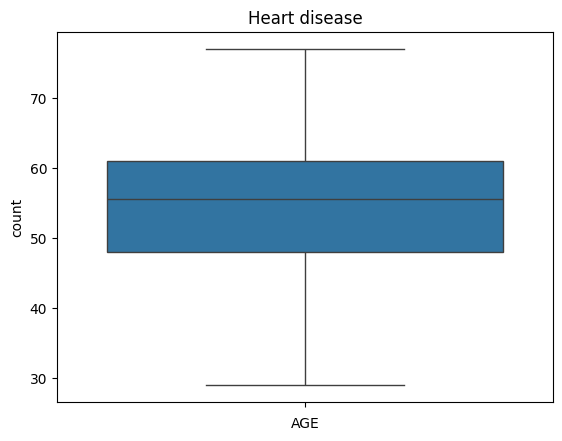

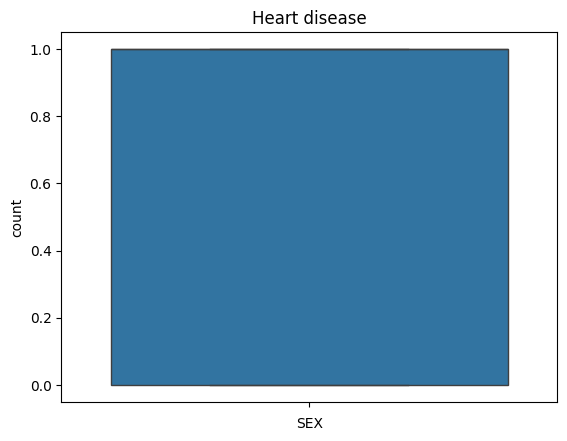

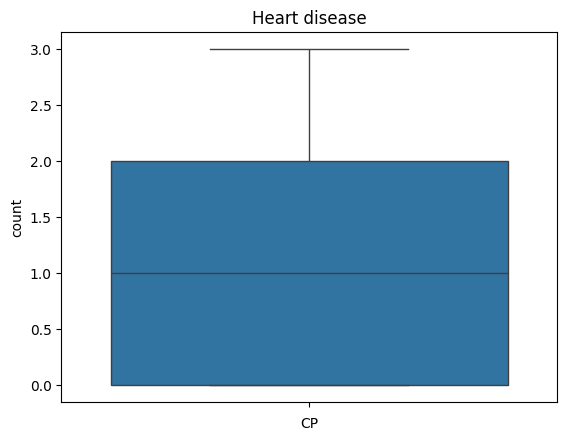

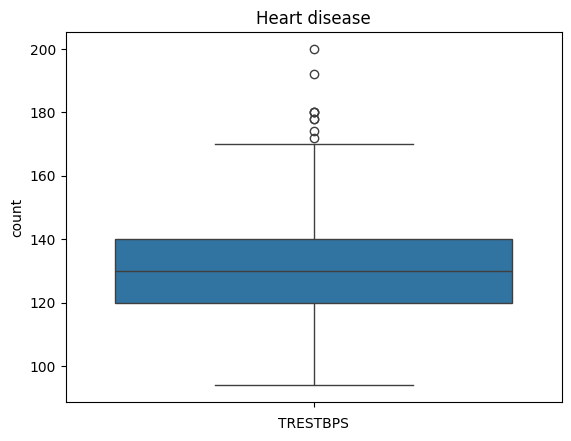

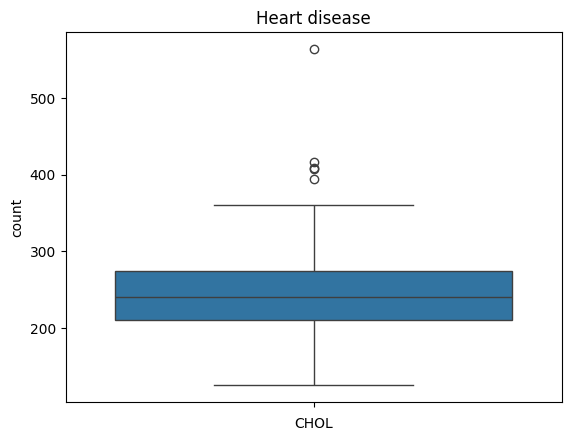

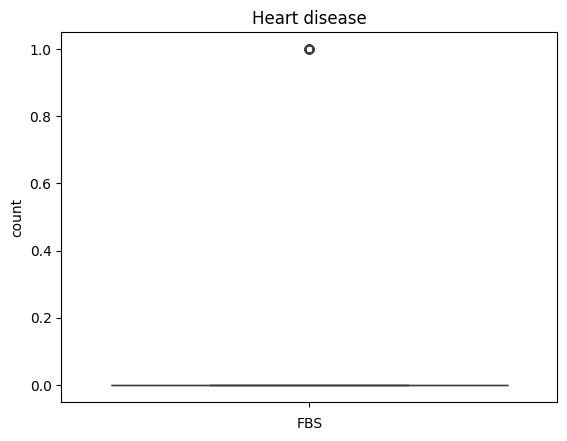

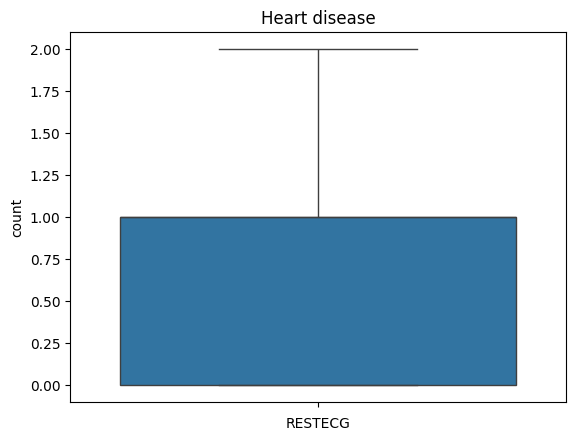

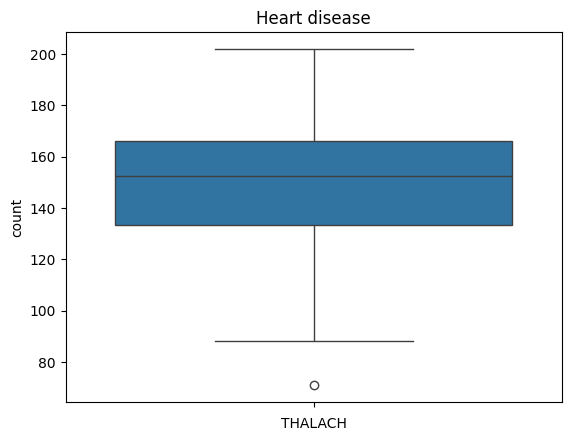

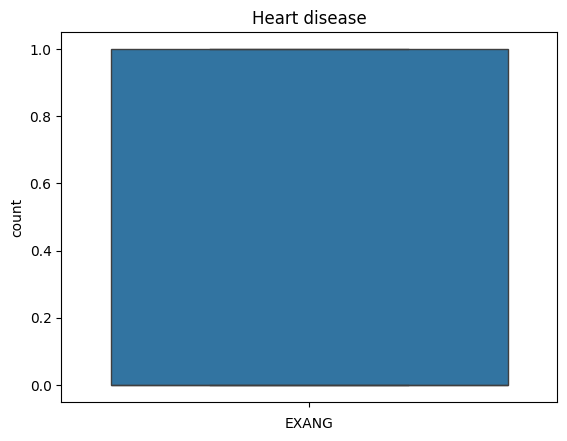

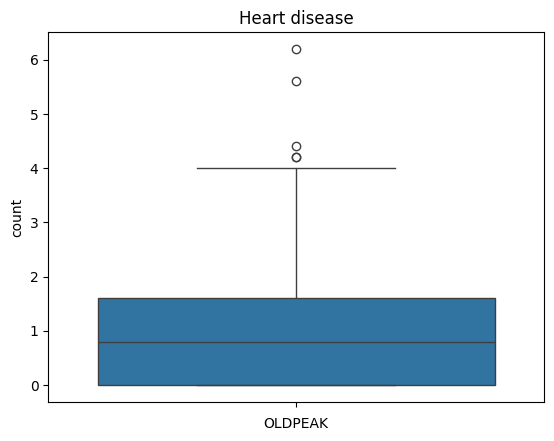

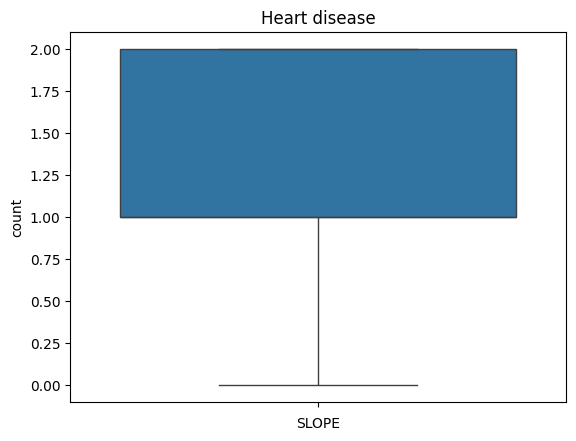

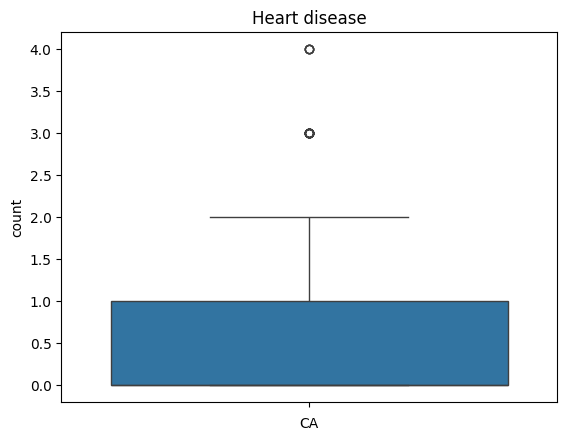

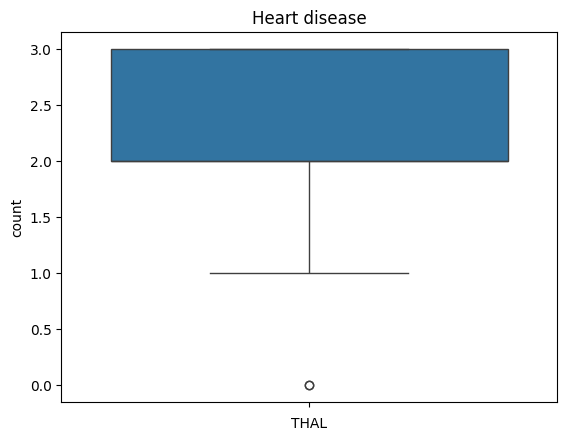

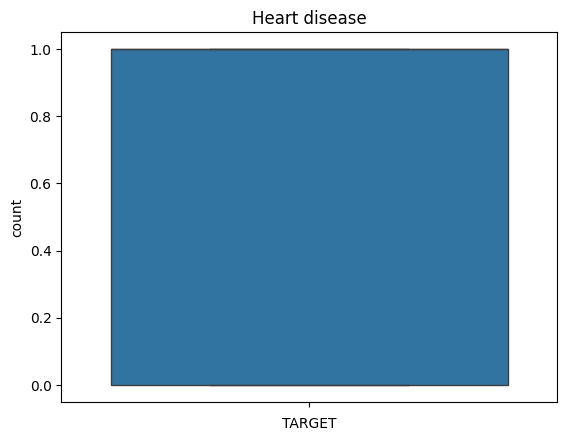

In [ ]:
for i in df.columns:
  if df[i].dtypes != "object":
    sns.boxplot(df[i])
    plt.title("Heart disease")
    plt.xlabel(i)
    plt.ylabel("count")
    plt.show()

In [ ]:
col=['TRESTBPS','CHOL','FBS','THALACH','OLDPEAK','CA','THAL']

In [ ]:
# from sklearn.preprocessing import LogTransform
# lt=LogTransform()
for i in col:
  df[i]=np.log1p(df[[i]])



/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


In [ ]:
df

,AGE,SEX,CP,TRESTBPS,CHOL,FBS,RESTECG,THALACH,EXANG,OLDPEAK,SLOPE,CA,THAL,TARGET
0,63,1,3,0.567621,-0.302843,1.220769,0,0.018651,0,0.734300,0,-1.254955,NaN,1
1,37,1,2,-0.095851,0.065545,-0.542052,1,0.969634,0,1.137489,0,-1.254955,-0.721535,1
2,41,0,1,-0.095851,-1.729143,-0.542052,0,0.683587,0,0.268380,2,-1.254955,-0.721535,1
3,56,1,1,-1.083857,-0.227179,-0.542052,1,0.807981,0,-0.235226,2,-1.254955,-0.721535,1
4,57,0,0,-1.083857,1.125125,-0.542052,1,0.462076,1,-0.481416,2,-1.254955,-0.721535,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,0.391305,-0.112552,-0.542052,1,NaN,1,-1.298504,1,-1.254955,0.751400,0
299,45,1,3,NaN,0.291701,-0.542052,1,-1.462673,0,0.126950,1,-1.254955,0.751400,0
300,68,1,0,0.534758,NaN,1.220769,1,-0.469650,0,1.109448,1,0.821971,0.751400,0
301,57,1,0,-0.095851,NaN,-0.542052,1,NaN,1,0.126950,1,0.246887,0.751400,0


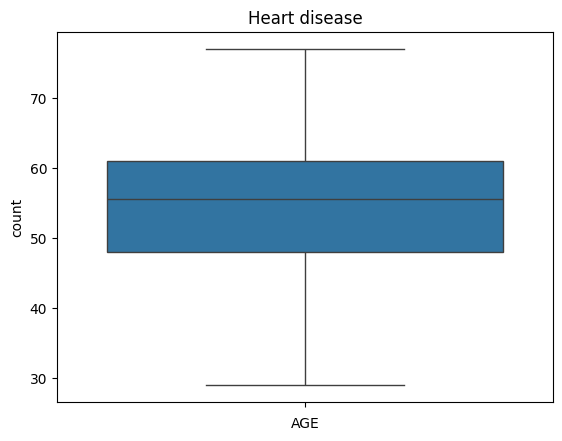

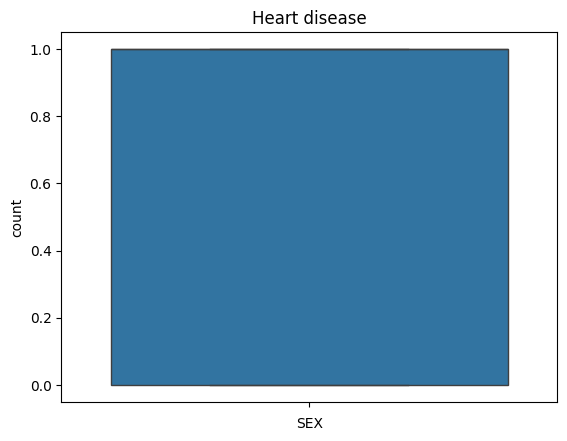

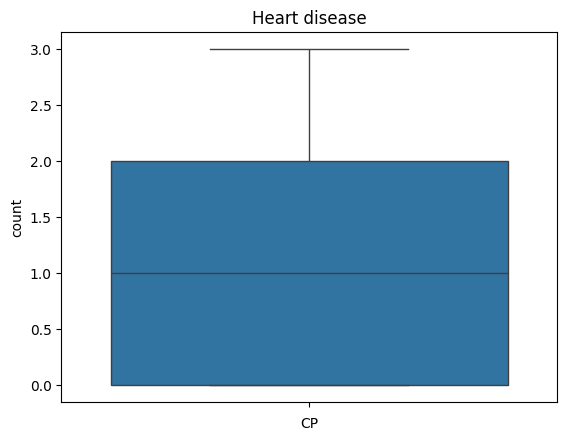

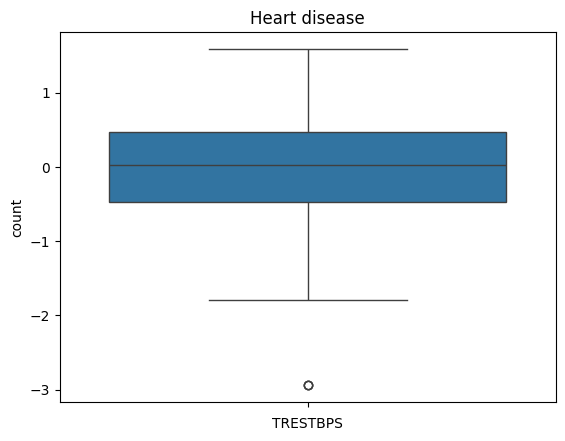

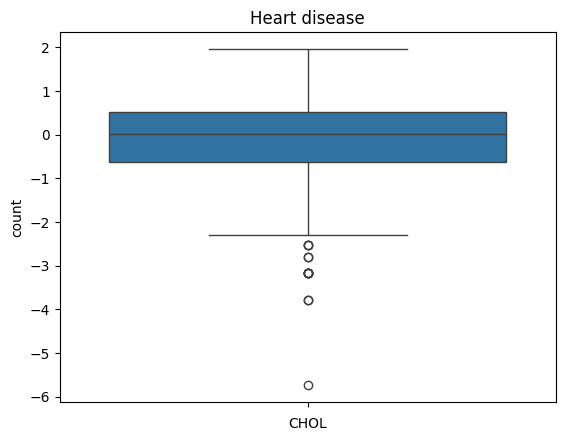

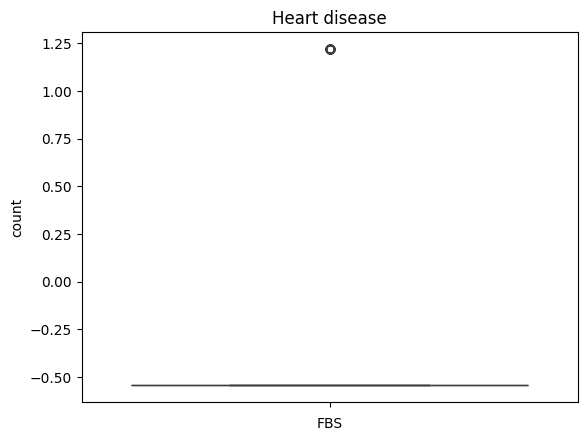

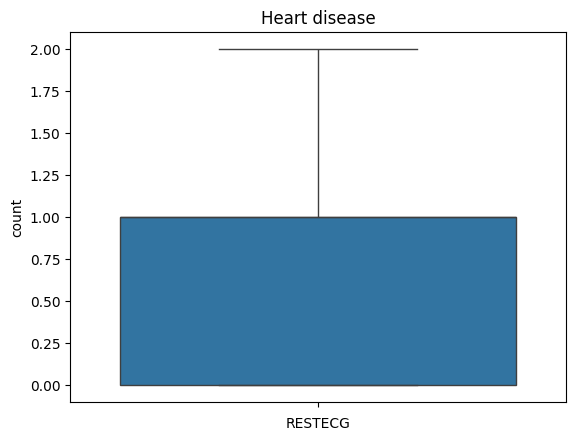

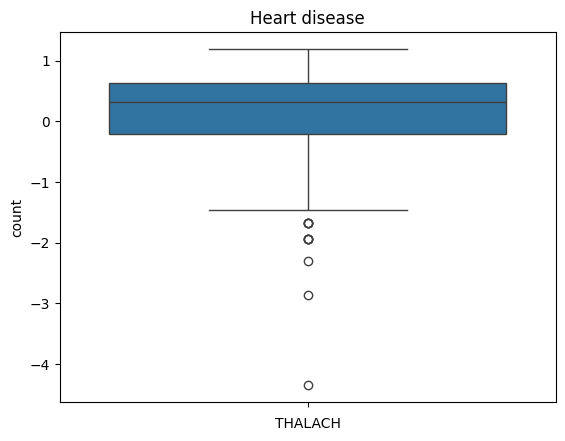

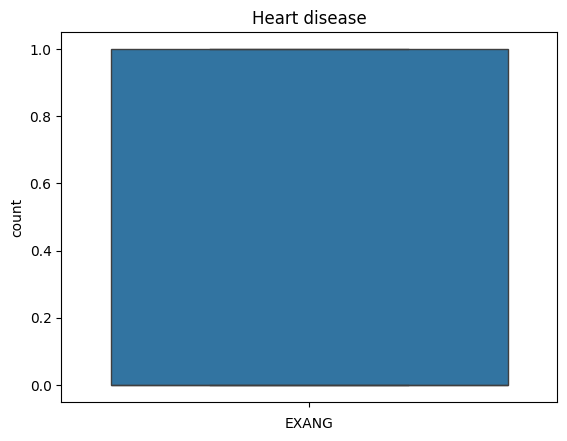

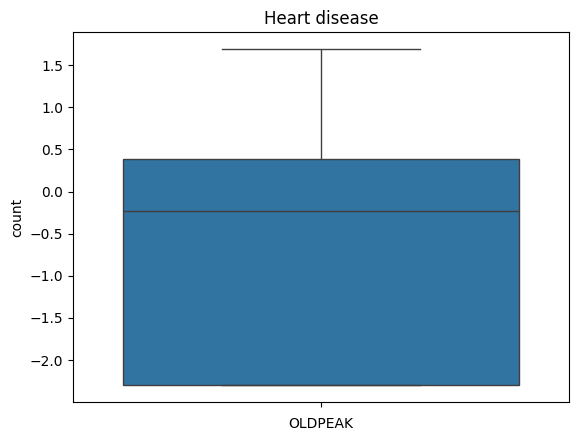

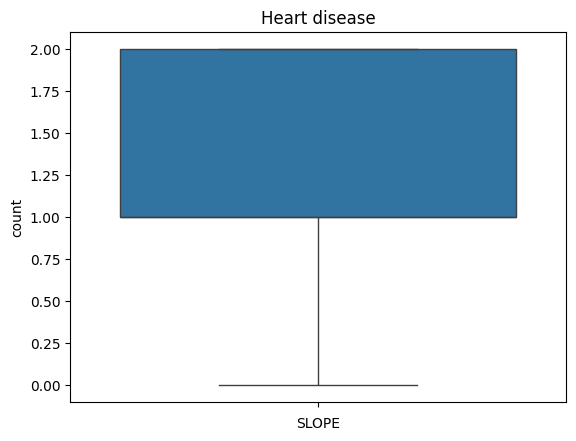

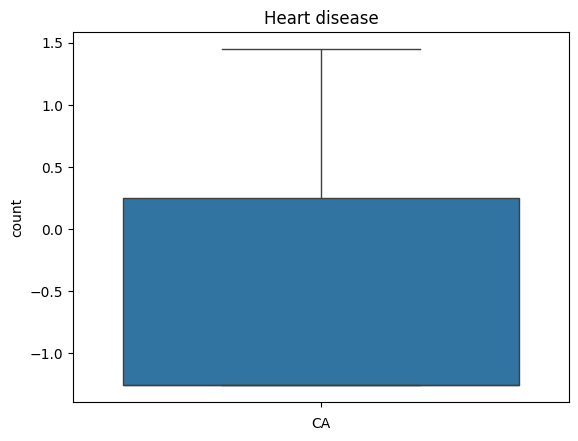

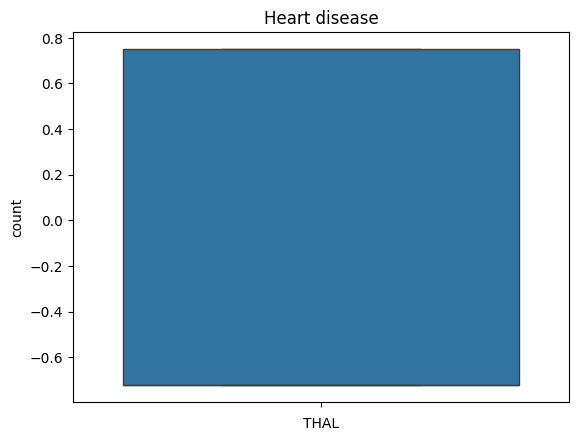

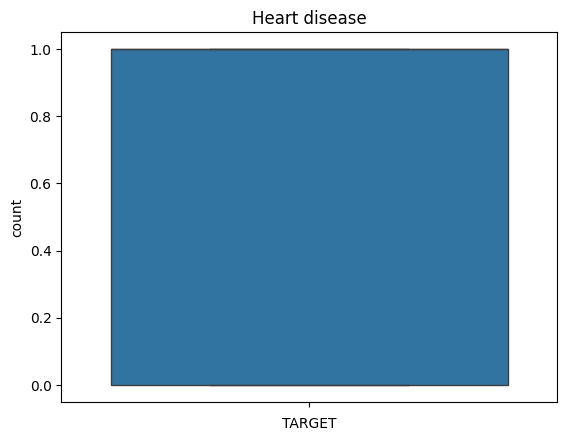

In [ ]:
for i in df.columns:
  if df[i].dtypes != "object":
    sns.boxplot(df[i])
    plt.title("Heart disease")
    plt.xlabel(i)
    plt.ylabel("count")
    plt.show()

In [ ]:
x=df.iloc[:,:-1]
y=df['TARGET']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dc=DecisionTreeClassifier(criterion='entropy')
dc.fit(x_train,y_train)
y_pred=dc.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score
print("Accuracy Score",accuracy_score(y_test,y_pred)*100)

Accuracy Score 80.32786885245902
